<a href="https://colab.research.google.com/github/aditya27you/Movie-Data-Analysis/blob/main/Google.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
pip install pytrends matplotlib pandas plotly

In [2]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq



# setup pytrend library and keyword define


In [14]:
pytrends = TrendReq(hl='en-US', tz = 360 )
keyword = 'Artificial intelligence'

# Data Request

In [17]:
pytrends.build_payload([keyword], cat=0, timeframe='today 12-m',geo='',gprop='')

# country wise interest

In [18]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by = keyword, ascending = False).head(15)

/tmp/ipython-input-417721252.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




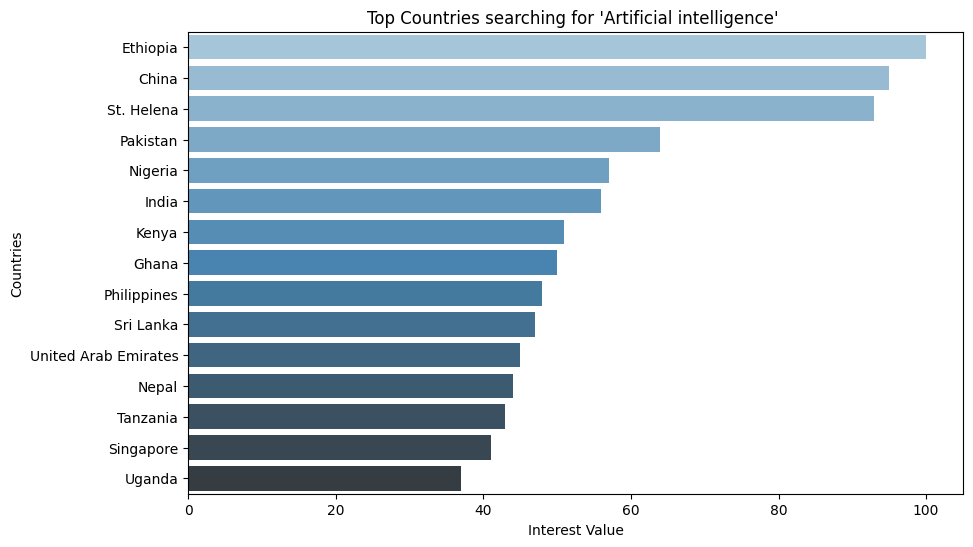

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(x = region_data[keyword], y = region_data.index, palette= "Blues_d")
plt.title( f"Top Countries searching for '{keyword}' ")
plt.xlabel("Interest Value")
plt.ylabel("Countries")
plt.show()

# World map for the above 15 country

In [20]:
region_data = region_data.reset_index()
fig = px.choropleth(region_data,
                    locations= 'geoName',
                    locationmode='country names',
                    title=f"Search Interest for '{keyword}' by country",
                    color_continuous_scale='Blues')
fig.show()

# Time wise interest

In [21]:
time_df = pytrends.interest_over_time()

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



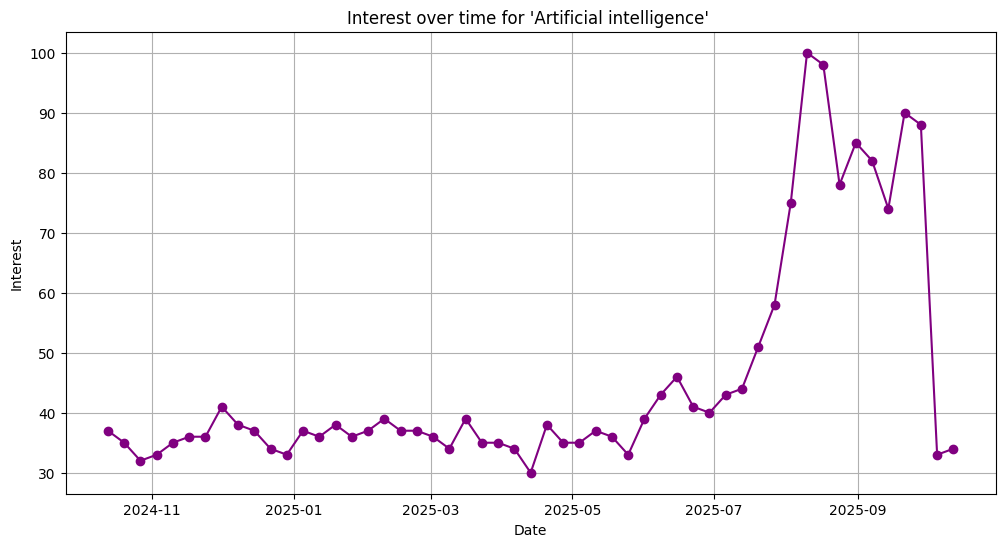

In [24]:
plt.figure(figsize=(12,6))
plt.plot(time_df.index, time_df[keyword], marker = 'o', color = 'purple')
plt.title(f"Interest over time for '{keyword}' ")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)

plt.show()

# compare related kerwords and plot the graph

In [31]:
ky_list = ["cloud computing" , "Artificial intelligence","data science"]
pytrends.build_payload(ky_list, cat=0, timeframe = 'today 12-m', geo = '')

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



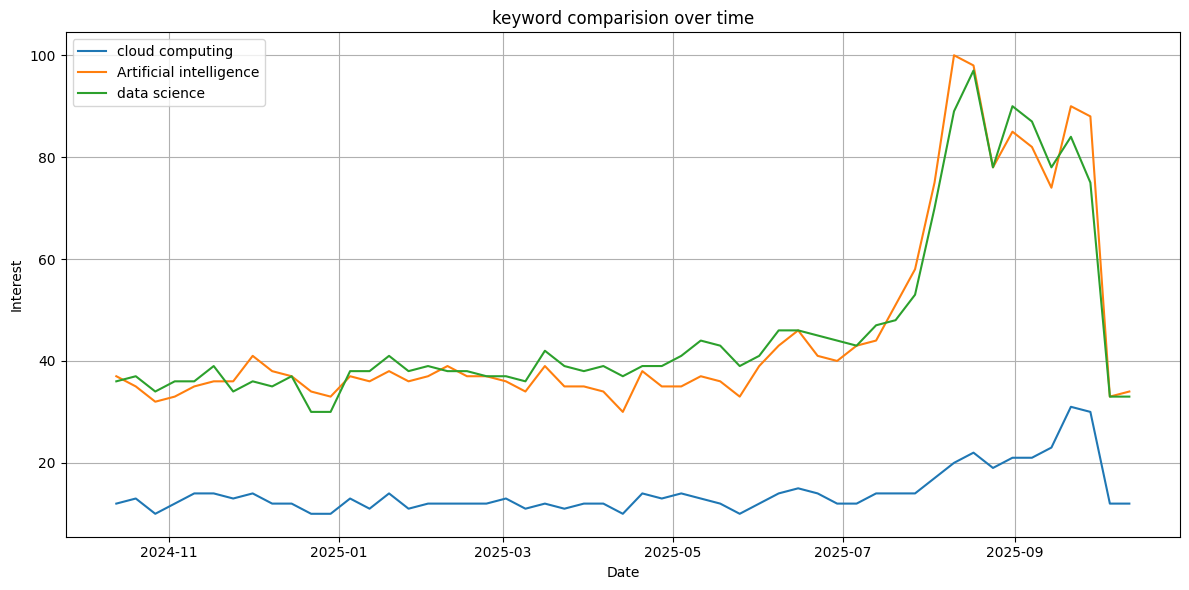

In [32]:
compare_df = pytrends.interest_over_time()
plt.figure(figsize=(12,6))
for kw in ky_list:
    plt.plot(compare_df.index, compare_df[kw], label = kw )
plt.title ("keyword comparision over time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()